In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sim_wrapper.sim import Sim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

In [2]:
sim = Sim(use_complex=False)

sim.add_param('w_0', 7.5e9 * 2 * np.pi)
sim.add_param('amp_in', 0.4) # signal amplitude
sim.add_param('kappa', 0.2e9 * 2 * np.pi)  # mode decay rate
sim.add_param('phase_in', 0)
sim.add_paramsweep('phi_DC', -1.5, 2, 200)
sim.add_param('epsilon', 0)
sim.add_param('w_phi', 1e9 * 2 * np.pi)
sim.add_paramsweep('w_in', 4e9*2*np.pi, 8e9*2*np.pi, 100, is_excitation=True) # signal frequency

sim.add_EOM('x1', 'x2')
sim.add_EOM('phi_flux', 'epsilon*w_phi*cos(w_phi*t)') # does nothing for now
sim.add_EOM('x2', '-kappa*x2 - w_0**2*abs(cos(phi_DC*pi))*sin(x1) + 2*kappa*(-amp_in*w_in*cos(w_in*t + phase_in))')
sim.add_EOM('x3','x2 + amp_in*w_in*cos(w_in*t + phase_in)')

sim.set_solve_type('decimate')

sim.specify_time(20, 400, d_factor=1)

sim.validate()

Simulation validation success!


C:\Users\boris\Documents\GitHub\gpu_odes\sim_wrapper\sim.py:148: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if self.excitation_freq == '':


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


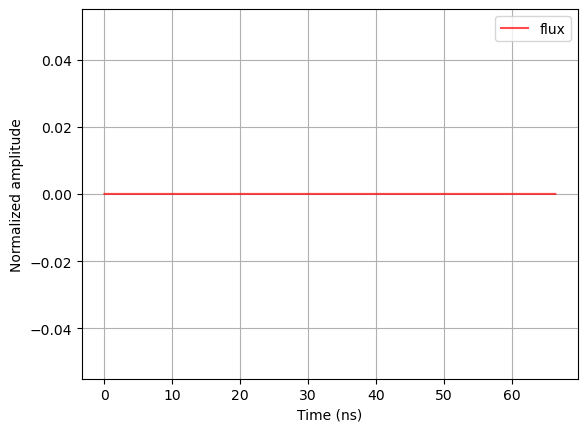

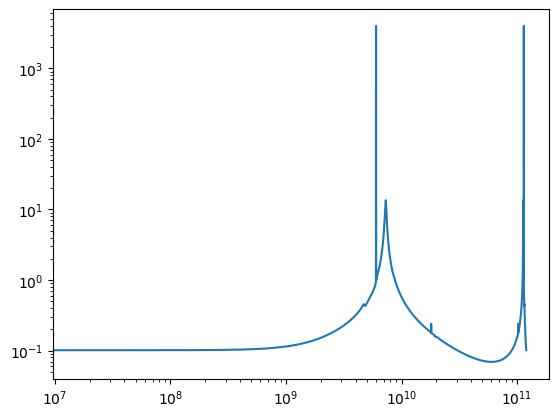

In [3]:
sim.param_dict_nosweep['amp_in'] = 1
sim.param_dict_nosweep['phi_DC'] = 0.1

x, t = sim.quick_trace()

plt.figure(1)
plt.plot(t*1e9, x[1,:],color=(1,0,0,0.7),label='flux')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()

plt.figure(2)
fftx = np.fft.fft(x[3, :])
freqs = np.linspace(0, len(t)/t[-1], len(t))
plt.loglog(freqs, np.abs(fftx).transpose())
# plt.xlim([3e9, 30e9])



In [4]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|████████████████████████████████████████████████████████████████████████████| 8000/8000 [00:03<00:00, 2159.88it/s]


 
...finished GPU solve!


Drive frequency: 5.575757575757576 GHz


Text(0.5, 1.0, 'Phase with bias current at drive frequency 5.575757575757576 GHz')

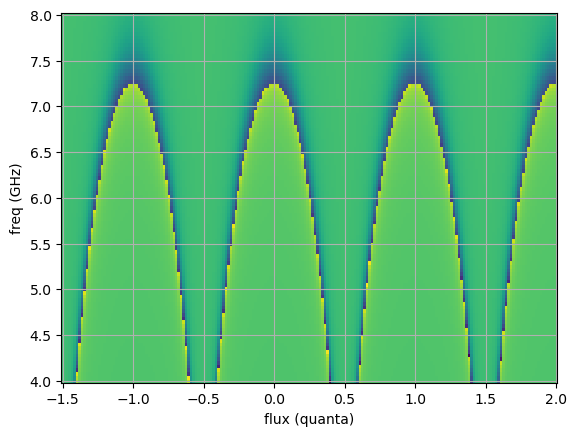

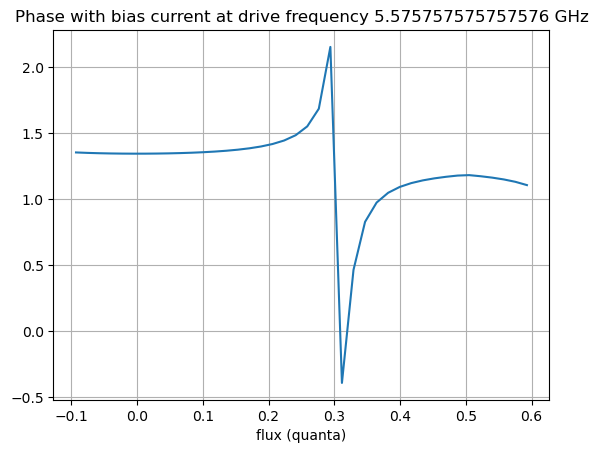

In [5]:
phase = np.angle(1j*Q+I)

plt.pcolor(sim.paramsweep_dict['phi_DC'],sim.paramsweep_dict['w_in']/(1e9*2*np.pi),  phase[3,:,:,-1].transpose())
plt.xlabel('flux (quanta)')
plt.ylabel('freq (GHz)')
plt.grid()

w_in_i = 39

print('Drive frequency: ' + str(sim.paramsweep_dict['w_in'][w_in_i]/(1e9*2*np.pi)) + ' GHz')

plt.figure()
plt.plot(sim.paramsweep_dict['phi_DC'][80:120],  np.unwrap(phase[3,80:120,w_in_i,-1]))
plt.xlabel('flux (quanta)')
plt.grid()
plt.title('Phase with bias current at drive frequency ' + str(sim.paramsweep_dict['w_in'][w_in_i]/(1e9*2*np.pi)) + ' GHz')


## Magnetic sensitivity test

Now we introduce a time varying external flux, picking 0.3 as flux bias (which confirms choice of paper)

In [24]:
sim = Sim(use_complex=False)

sim.add_param('w_0', 7.5e9 * 2 * np.pi)
sim.add_param('logamp_in', -2) # signal amplitude
sim.add_param('kappa', 0.2e9 * 2 * np.pi)  # mode decay rate
sim.add_param('phase_in', 0)
sim.add_param('phi_DC', 0.1)
sim.add_param('epsilon', 0)
sim.add_param('w_phi', 0.5e9 * 2 * np.pi)
sim.add_paramsweep('w_d', 4e9*2*np.pi, 6e9*2*np.pi, 101, is_excitation=True) # drive frequency (from paper)
sim.add_param('w_demod', 5e9*2*np.pi) # demod

sim.add_EOM('x1', 'x2')
sim.add_EOM('phi_flux', 'epsilon*w_phi*cos(w_phi*t)* ((tanh((t-1e-7)/1e-8))+1)', IC=sim.param_dict['phi_DC'])
sim.add_EOM('x2', '-kappa*x2 - w_0**2*abs(cos(phi_flux*2*pi))*sin(x1) + 2*kappa*(- (10**logamp_in) *w_d*cos(w_d*t + phase_in))')
sim.add_EOM('x3','x2 + (10**logamp_in) *w_d*cos(w_d*t + phase_in)')


sim.set_solve_type('decimate')

sim.specify_time(20, 5000, d_factor=1)

sim.validate()

Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


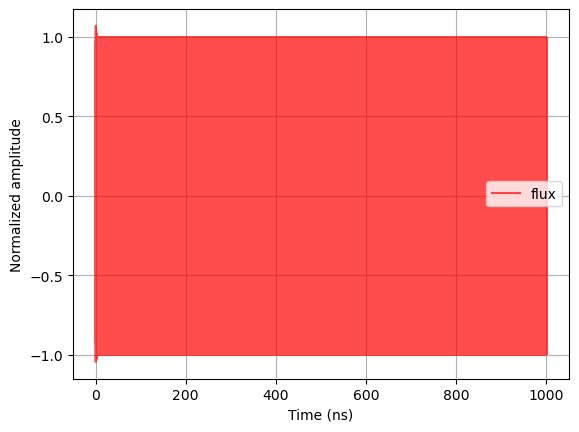

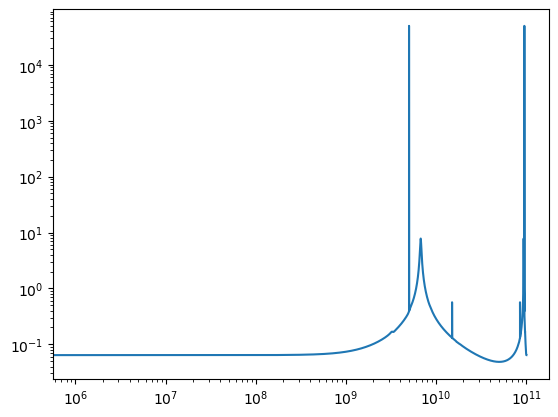

In [29]:
sim.param_dict_nosweep['logamp_in'] = 0
sim.param_dict_nosweep['epsilon'] = 0.0

x, t = sim.quick_trace()

plt.figure(1)
plt.plot(t*1e9, x[3,:],color=(1,0,0,0.7),label='flux')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()

plt.figure(2)
fftx = np.fft.fft(x[3, :])
freqs = np.linspace(0, len(t)/t[-1], len(t))
plt.loglog(freqs, np.abs(fftx).transpose())



In [8]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:46<00:00, 2172.24it/s]


 
...finished GPU solve!


In [9]:
factor = 10
shape = list(np.shape(I))
newshape = shape.copy()
newshape.append(factor)
newshape[-2] = newshape[-2]//factor

Id = np.sum(np.reshape(I,newshape),axis=-1)
Qd = np.sum(np.reshape(Q,newshape),axis=-1)

shape = list(np.shape(t))
newshape = shape.copy()
newshape.append(factor)
newshape[-2] = newshape[-2]//factor

td = np.sum(np.reshape(t,newshape),axis=-1)

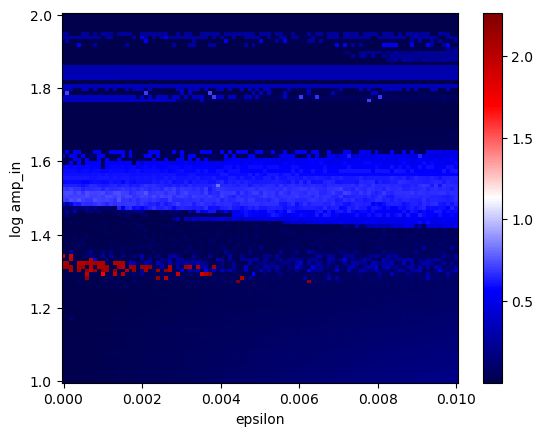

In [10]:
mag = np.sqrt(Id[3,:,:,:]**2 + Qd[3,:,:,:]**2)

logamp_in = sim.paramsweep_dict['logamp_in']

amp_in = 10**logamp_in
epsilon = sim.paramsweep_dict['epsilon']

EPSILON, AMP_IN = np.meshgrid(epsilon, amp_in)


plt.pcolor(epsilon, logamp_in, np.mean(mag, axis=-1)/AMP_IN,cmap='seismic')
plt.xlabel('epsilon')
plt.ylabel('log amp_in')
plt.colorbar()